<a href="https://colab.research.google.com/github/K-REDWAN/DATA-SCIENCE-JOURNEY/blob/main/Mini_Visual_project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

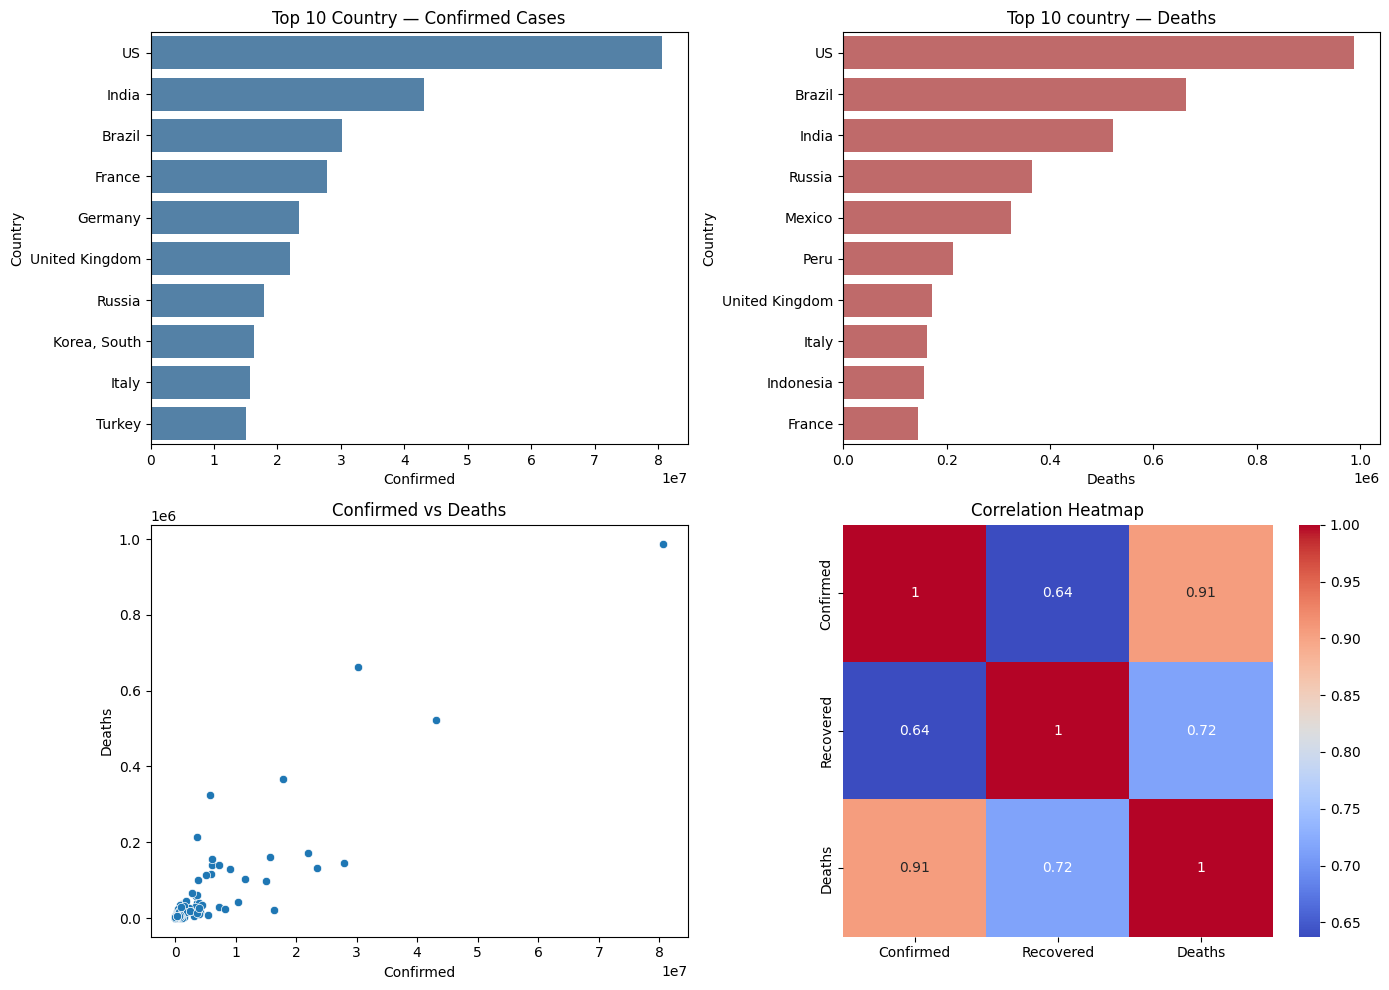

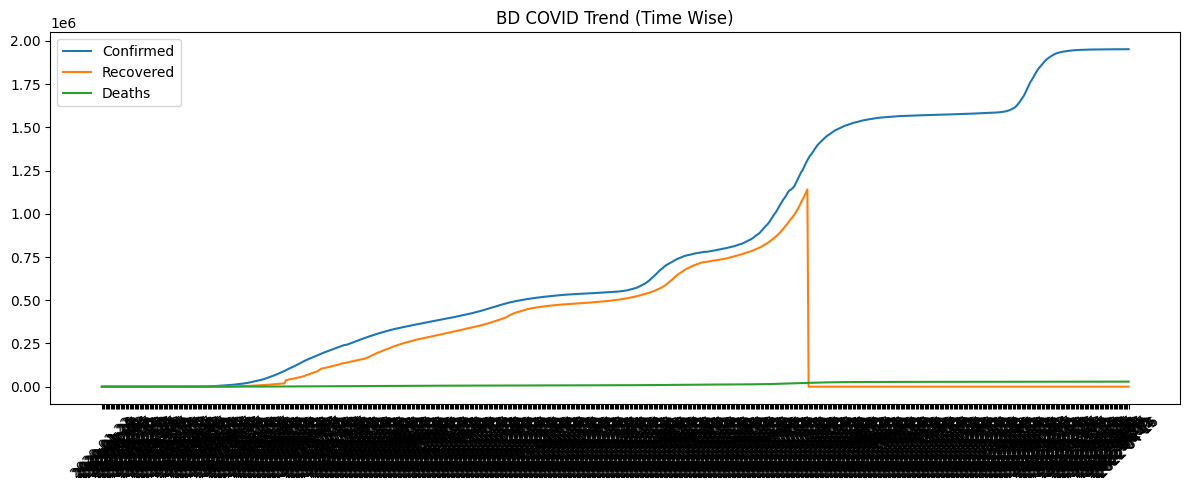

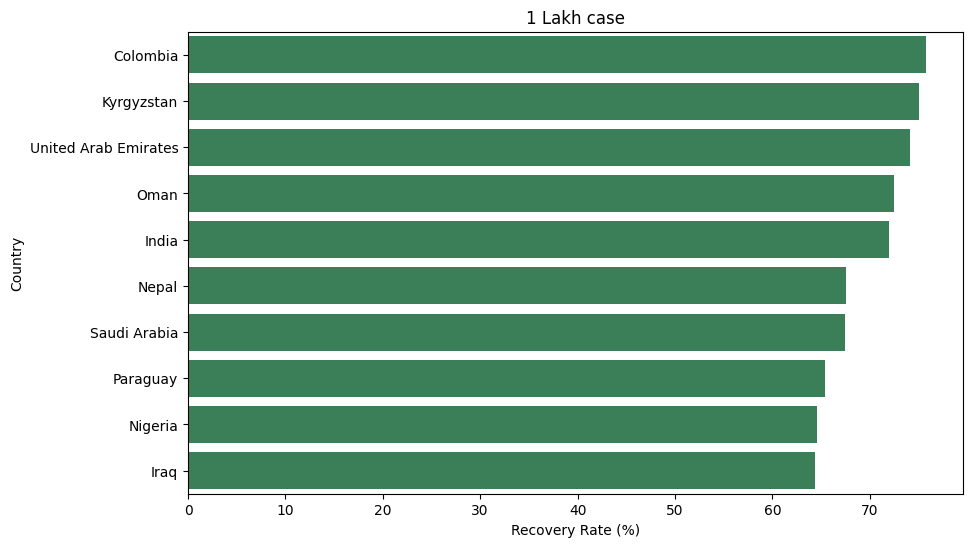

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/datasets/covid-19/main/data/countries-aggregated.csv"
df = pd.read_csv(url)

summary = df.groupby("Country")[["Confirmed", "Recovered", "Deaths"]].max()
summary["Recovery_Rate"] = (summary["Recovered"] / summary["Confirmed"]) * 100
summary["Death_Rate"] = (summary["Deaths"] / summary["Confirmed"]) * 100

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# চার্ট ১: Top 10 Confirmed
top10 = summary.sort_values("Confirmed", ascending=False).head(10)
sns.barplot(x=top10["Confirmed"], y=top10.index, ax=axes[0,0], color="steelblue")
axes[0,0].set_title("Top 10 Country — Confirmed Cases")

# চার্ট ২: Top 10 Deaths
top10_deaths = summary.sort_values("Deaths", ascending=False).head(10)
sns.barplot(x=top10_deaths["Deaths"], y=top10_deaths.index, ax=axes[0,1], color="indianred")
axes[0,1].set_title("Top 10 country — Deaths")

# চার্ট ৩: Confirmed vs Deaths সম্পর্ক
sns.scatterplot(data=summary, x="Confirmed", y="Deaths", ax=axes[1,0])
axes[1,0].set_title("Confirmed vs Deaths")

# চার্ট ৪: Correlation Heatmap
sns.heatmap(summary[["Confirmed","Recovered","Deaths"]].corr(), annot=True, cmap="coolwarm", ax=axes[1,1])
axes[1,1].set_title("Correlation Heatmap")

plt.tight_layout()
plt.savefig("covid_dashboard.png", dpi=150)
plt.show()


bd = df[df["Country"] == "Bangladesh"]

plt.figure(figsize=(12, 5))
plt.plot(bd["Date"], bd["Confirmed"], label="Confirmed")
plt.plot(bd["Date"], bd["Recovered"], label="Recovered")
plt.plot(bd["Date"], bd["Deaths"], label="Deaths")
plt.legend()
plt.title("BD COVID Trend (Time Wise)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("bangladesh_trend.png", dpi=150)
plt.show()

top_recovery = summary[summary["Confirmed"] > 100000].sort_values("Recovery_Rate", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_recovery["Recovery_Rate"], y=top_recovery.index, color="seagreen")
plt.title("1 Lakh case")
plt.xlabel("Recovery Rate (%)")
plt.savefig("recovery_rate.png", dpi=150)
plt.show()

